# Question 1 Random Forest: Mean Trait Model

This notebook evaluates the custom CSC 466 random forest using `data/processed/breed_traits_mean.csv`.

This version replaces the individual AKC trait ratings with grouped mean features: family life, physical, social, personality, and all-traits mean.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

for base_dir in [Path.cwd(), *Path.cwd().parents]:
    if (base_dir / "data").exists() and (base_dir / "models").exists():
        PROJECT_ROOT = base_dir
        break
else:
    raise FileNotFoundError("Could not find project root with data/ and models/ folders.")

sys.path.insert(0, str(PROJECT_ROOT))

from models.randomForest.gridSearch import build_rf, run_grid_search
from models.readCSV import read_csv

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "breed_traits_mean.csv"
GRID_PATH = PROJECT_ROOT / "configs" / "rf_grid_search_params.csv"
PREDICTION_OUTPUT_PATH = PROJECT_ROOT / "results" / "question1" / "rf_mean_test_predictions.csv"

In [3]:
best_params = run_grid_search(DATA_PATH, GRID_PATH)

In [4]:
X, y, attributes = read_csv(str(DATA_PATH))
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [5]:
best_rf = build_rf(best_params, seed=42)
best_rf.fit(X_train, y_train, attributes)
test_predictions = best_rf.predict(X_test)
label_order = ["High Popularity", "Medium Popularity", "Low Popularity"]

## Model Interpretation

To interpret the model, these tables show which grouped features the forest split on most often and how average grouped trait values differ across the actual popularity tiers.


In [6]:
def collect_split_counts(forest):
    split_counts = {}

    def walk(tree_part):
        if "node" not in tree_part:
            return

        node = tree_part["node"]
        feature = node["var"]
        split_counts[feature] = split_counts.get(feature, 0) + 1

        for edge_wrapper in node["edges"]:
            edge = edge_wrapper["edge"]
            if "node" in edge:
                walk({"node": edge["node"]})

    for tree in forest:
        walk(tree.tree)

    return (
        pd.DataFrame(
            [{"Feature": feature, "Split Count": count} for feature, count in split_counts.items()]
        )
        .sort_values("Split Count", ascending=False)
        .reset_index(drop=True)
    )

split_importance = collect_split_counts(best_rf.forest)
split_importance

,Feature,Split Count
0,Personality,99
1,Social,91
2,Physical,78
3,Family Life,60


In [14]:
numeric_cols = [col for col in X.columns if X[col].dtype.name != "category"]
categorical_cols = [col for col in X.columns if X[col].dtype.name == "category"]

trait_profile = (
    X.assign(Popularity_Tier=y.astype(str))
    .groupby("Popularity_Tier")[numeric_cols]
    .mean()
    .reindex(label_order)
    .T
)

trait_profile

Popularity_Tier,High Popularity,Medium Popularity,Low Popularity
Family Life,4.278912,3.815789,3.939394
Physical,2.387755,2.267544,2.038961
Social,3.897959,3.707237,3.461039
Personality,3.750000,3.523026,3.597403


In [8]:
category_profile = (
    X.assign(Popularity_Tier=y.astype(str))
    .groupby("Popularity_Tier")[categorical_cols]
    .agg(lambda values: values.mode().iloc[0] if not values.mode().empty else "")
    .reindex(label_order)
)

category_profile

,Coat Type,Coat Length
Popularity_Tier,,
High Popularity,Smooth,Short
Medium Popularity,Smooth,Medium
Low Popularity,Smooth,Short


In [9]:
print(classification_report(y_test, test_predictions, labels=label_order, zero_division=0))

                   precision    recall  f1-score   support

  High Popularity       1.00      0.20      0.33        10
Medium Popularity       0.50      0.40      0.44        15
   Low Popularity       0.52      0.88      0.65        16

         accuracy                           0.54        41
        macro avg       0.67      0.49      0.48        41
     weighted avg       0.63      0.54      0.50        41



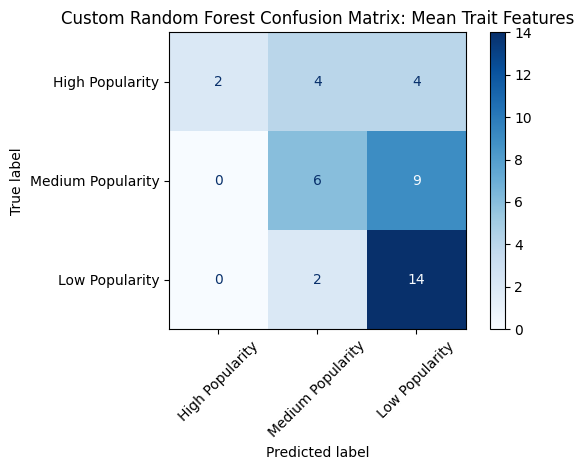

In [10]:
cm = confusion_matrix(y_test, test_predictions, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Custom Random Forest Confusion Matrix: Mean Trait Features")
plt.tight_layout()
plt.show()

## Prediction CSV

This output compares each test-set breed's actual popularity tier to the tier predicted by the mean-trait random forest model.

In [11]:
PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

breed_names = (
    pd.read_csv(DATA_PATH)
    .drop(index=[0, 1])
    .reset_index(drop=True)["Breed"]
)

prediction_results = pd.DataFrame(
    {
        "Breed": breed_names.loc[X_test.index].reset_index(drop=True),
        "Actual Popularity Tier": y_test.astype(str).reset_index(drop=True),
        "Predicted Popularity Tier": pd.Series(test_predictions).astype(str),
    }
)
prediction_results["Correct"] = (
    prediction_results["Actual Popularity Tier"]
    == prediction_results["Predicted Popularity Tier"]
)

prediction_results.to_csv(PREDICTION_OUTPUT_PATH, index=False)
prediction_results

,Breed,Actual Popularity Tier,Predicted Popularity Tier,Correct
0,Doberman Pinscher,High Popularity,Medium Popularity,False
1,Dogue de Bordeaux,Medium Popularity,Medium Popularity,True
2,Sussex Spaniel,Low Popularity,Medium Popularity,False
3,Australian Cattle Dog,Medium Popularity,Low Popularity,False
4,Maltese,High Popularity,Low Popularity,False
5,Silky Terrier,Medium Popularity,Low Popularity,False
6,Yorkshire Terrier,High Popularity,Medium Popularity,False
7,Chinese Shar-Pei,Medium Popularity,Low Popularity,False
8,Lakeland Terrier,Low Popularity,Low Popularity,True
9,Akita,Medium Popularity,Medium Popularity,True
